In [1]:
import cv2
import mediapipe as mp
import numpy as np
import matplotlib.pyplot as plt

In [2]:
mp_hands = mp.solutions.hands
mp_draw = mp.solutions.drawing_utils

# Capture & Draw Landmarks

In [3]:
def extract_keypoints(results):
    if not results.multi_hand_landmarks:
        return np.zeros(21*3)

    hand_landmarks = results.multi_hand_landmarks[0]

    keypoints = []
    for lm in hand_landmarks.landmark:
        keypoints.append(lm.x)
        keypoints.append(lm.y)
        keypoints.append(lm.z)

    return np.array(keypoints)

In [4]:
cap = cv2.VideoCapture(0)

with mp_hands.Hands(
    max_num_hands=1,
    model_complexity=1,
    min_detection_confidence=0.7,
    min_tracking_confidence=0.7
) as hands:

    while True:
        ret, frame = cap.read()
        if not ret:
            break
    
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    
        results = hands.process(rgb_frame)
    
        if results.multi_hand_landmarks:
            for hand_landmarks in results.multi_hand_landmarks:
                mp_draw.draw_landmarks(frame, hand_landmarks, mp_hands.HAND_CONNECTIONS)
        
        cv2.imshow("Hand Tracking", frame)
    
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

cap.release()
cv2.destroyAllWindows()

In [3]:
# plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

# Save Landmarks To Create The Dataset

In [8]:
import os
os.makedirs('dataset/true', exist_ok=True)
os.makedirs('dataset/false', exist_ok=True)

In [12]:

cap = cv2.VideoCapture(0)

sample_id_true = 253
sample_id_false = 0

with mp_hands.Hands(
    max_num_hands=1,
    model_complexity=1,
    min_detection_confidence=0.7,
    min_tracking_confidence=0.7
) as hands:

    while True:
        ret, frame = cap.read()
        if not ret:
            break
    
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = hands.process(rgb_frame)
    
        if results.multi_hand_landmarks:
            for hand_landmarks in results.multi_hand_landmarks:
                mp_draw.draw_landmarks(frame, hand_landmarks, mp_hands.HAND_CONNECTIONS)

        keypoints = extract_keypoints(results)

        key = cv2.waitKey(1) & 0xFF
        if  key == ord('t'):
            np.save(f"dataset/true/{sample_id_true}.npy", keypoints)
            print(f"saved TRUE sample #{sample_id_true}")
            sample_id_true += 1

        if key == ord('f'):
            np.save(f"dataset/false/{sample_id_false}.npy", keypoints)
            print(f"saved FALSE sample #{sample_id_false}")
            sample_id_false += 1
    
        if key == ord('q'):
            break

        cv2.imshow("Hand Tracking", frame)

cap.release()
cv2.destroyAllWindows()

saved TRUE sample #253
saved TRUE sample #254
saved TRUE sample #255
saved TRUE sample #256
saved TRUE sample #257
saved TRUE sample #258
saved TRUE sample #259
saved TRUE sample #260
saved TRUE sample #261
saved TRUE sample #262
saved TRUE sample #263
saved TRUE sample #264
saved TRUE sample #265
saved TRUE sample #266
saved TRUE sample #267
saved TRUE sample #268
saved TRUE sample #269
saved TRUE sample #270
saved TRUE sample #271
saved TRUE sample #272
saved TRUE sample #273
saved TRUE sample #274
saved TRUE sample #275
saved TRUE sample #276
saved TRUE sample #277
saved TRUE sample #278
saved TRUE sample #279
saved TRUE sample #280
saved TRUE sample #281
saved TRUE sample #282
saved TRUE sample #283
saved TRUE sample #284
saved TRUE sample #285
saved TRUE sample #286
saved TRUE sample #287
saved TRUE sample #288
saved TRUE sample #289
saved TRUE sample #290
saved TRUE sample #291
saved TRUE sample #292
saved TRUE sample #293
saved TRUE sample #294
saved TRUE sample #295
saved TRUE 

In [8]:
cap.release()
cv2.destroyAllWindows()

# Load Arrays To Create The Dataset

In [9]:
from sklearn.model_selection import train_test_split
from collections import Counter

In [10]:
def load_npy_folder(folder):
    files = sorted([os.path.join(folder, f) for f in os.listdir(folder) if f.endswith('.npy')])
    data = []
    for f in files:
        try:
            arr = np.load(f)
            data.append(arr)
        except Exception as e:
            print(f"Couldn't load {f}: {e}")
    return data

In [11]:
TRUE_DIR = "dataset/true"
FALSE_DIR = "dataset/false"

true_samples = load_npy_folder(TRUE_DIR)
false_samples = load_npy_folder(FALSE_DIR)

In [12]:
X_true = np.vstack(true_samples) if len(true_samples) else np.empty((0, 63))
X_false = np.vstack(false_samples) if len(false_samples) else np.empty((0, 63))
y_true = np.ones(len(X_true), dtype=np.int32)
y_false = np.zeros(len(X_false), dtype=np.int32)

In [13]:
X = np.vstack([X_true, X_false])
y = np.concatenate([y_true, y_false])

In [14]:
Counter(y)

Counter({np.int32(1): 425, np.int32(0): 401})

In [15]:
TEST_SIZE = 0.2
RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, shuffle=True, stratify=y
)

In [16]:
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train class counts:", Counter(y_train))
print("Test class counts:", Counter(y_test))

Train shape: (660, 63) Test shape: (166, 63)
Train class counts: Counter({np.int32(1): 340, np.int32(0): 320})
Test class counts: Counter({np.int32(1): 85, np.int32(0): 81})


# Train The NN Model

In [40]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import matplotlib.pyplot as plt

In [51]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [52]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [53]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,561 (72.50 KB)

 Trainable params: 18,561 (72.50 KB)

 Non-trainable params: 0 (0.00 B)

In [54]:
history = model.fit(
    X_train, y_train,
    epochs=60,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6136 - loss: 0.6614 - val_accuracy: 0.6591 - val_loss: 0.6240
Epoch 2/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6989 - loss: 0.5930 - val_accuracy: 0.6970 - val_loss: 0.5865
Epoch 3/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7102 - loss: 0.5619 - val_accuracy: 0.6970 - val_loss: 0.5736
Epoch 4/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7216 - loss: 0.5429 - val_accuracy: 0.7273 - val_loss: 0.5137
Epoch 5/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7443 - loss: 0.5150 - val_accuracy: 0.7652 - val_loss: 0.4973
Epoch 6/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7879 - loss: 0.4564 - val_accuracy: 0.8258 - val_loss: 0.4073
Epoch 7/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8447 - loss: 0.3934 - val_accuracy: 0.9091 - val_loss: 0.3164
Epoch 8/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8466 - loss: 0.3752 - val_accuracy: 0.8712 - val_loss

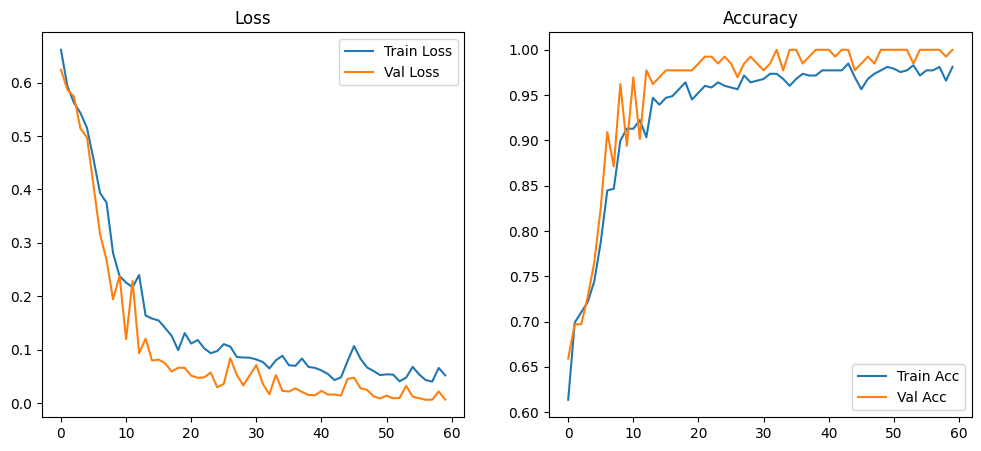

In [55]:
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Val Loss")
plt.title("Loss")
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label="Train Acc")
plt.plot(history.history['val_accuracy'], label="Val Acc")
plt.title("Accuracy")
plt.legend()

plt.show()

# Evaluate The Model

In [56]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


In [57]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1 Score :", f1)

Accuracy : 0.9759036144578314
Precision: 0.9550561797752809
Recall   : 1.0
F1 Score : 0.9770114942528736


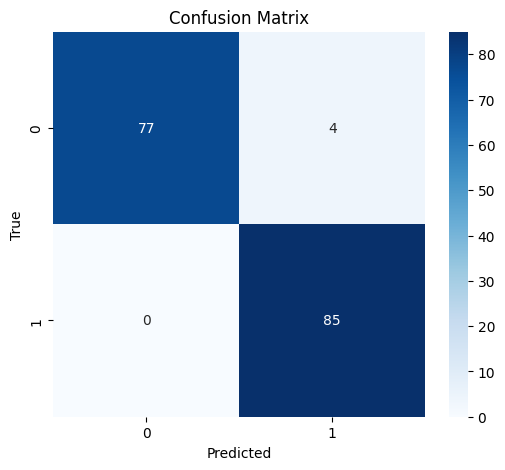

In [59]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Save Weights

In [ ]:
model.save('nn_project.h5')

# Test in Real Time

In [5]:
from tensorflow.keras.models import load_model

model = load_model('nn_project.h5')

In [18]:
y_probs = model.predict(X_test)
y_probs.shape

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


(166, 1)

In [19]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = roc_auc_score(y_test, y_probs)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9996368917937546


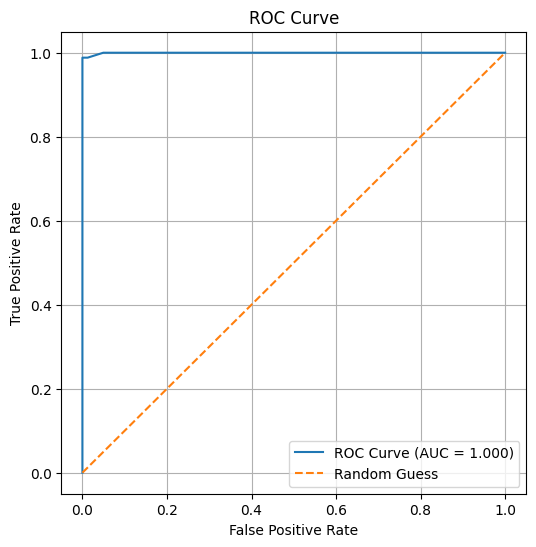

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

In [5]:
cap = cv2.VideoCapture(0)

with mp_hands.Hands(
    max_num_hands=1,
    model_complexity=1,
    min_detection_confidence=0.7,
    min_tracking_confidence=0.7
) as hands:

    while True:
        ret, frame = cap.read()
        # if not ret:
        #     break
    
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    
        results = hands.process(rgb_frame)

        keypoints = extract_keypoints(results)

        if np.any(keypoints):
            pred = model.predict(np.array([keypoints]), verbose=0)[0][0]
            prediction = "True" if pred > 0.75 else "False"
            conf = float(pred)
        else:
            prediction = "No Hand"
            conf = 0.0
        
        if results.multi_hand_landmarks:
            for hand_landmarks in results.multi_hand_landmarks:
                mp_draw.draw_landmarks(frame, hand_landmarks, mp_hands.HAND_CONNECTIONS)

        cv2.putText(frame, f"Prediction: {prediction} ({conf:.2f})",
                (10, 40), cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)
        
        cv2.imshow("Real-Time Test", frame)
    
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

cap.release()
cv2.destroyAllWindows()

D:\anaconda3\envs\lstm_env\lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


In [6]:
cap.release()
cv2.destroyAllWindows()

In [40]:
np.array(extract_keypoints(results)).shape

(63,)

In [41]:
# X_test[0].shape

In [49]:
model.predict(np.array([extract_keypoints(results)]))[0][0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


np.float32(0.0054462776)

# Use Pyautogui To Move The Cursor

In [6]:
import pyautogui
from filterpy.kalman import KalmanFilter

In [7]:
pyautogui.FAILSAFE = False
pyautogui.MINIMUM_DURATION = 0
pyautogui.MINIMUM_SLEEP = 0
pyautogui.PAUSE = 0

In [10]:
cap = cv2.VideoCapture(0)
smooth_x, smooth_y = 0, 0
alpha = 0.25

with mp_hands.Hands(
    max_num_hands=1,
    model_complexity=0,
    min_detection_confidence=0.6,
    min_tracking_confidence=0.6
) as hands:

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        small_frame = cv2.resize(frame, (320, 240))
        rgb = cv2.cvtColor(small_frame, cv2.COLOR_BGR2RGB)

        results = hands.process(rgb)

        if results.multi_hand_landmarks:
            hand = results.multi_hand_landmarks[0]

            keypoints = extract_keypoints(results)
            keypoints = np.array(keypoints).reshape(1, -1)

            pred = model.predict(keypoints, verbose=0)[0][0]

            if pred > 0.75:
                index_tip = hand.landmark[8]

                screen_w, screen_h = pyautogui.size()
                target_x = int((1 - index_tip.x) * screen_w)
                target_y = int(index_tip.y * screen_h)

                smooth_x = int(alpha * target_x + (1 - alpha) * smooth_x)
                smooth_y = int(alpha * target_y + (1 - alpha) * smooth_y)

                pyautogui.moveTo(smooth_x, smooth_y, duration=0)

        cv2.imshow("Cursor Control", frame)
    
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

cap.release()
cv2.destroyAllWindows()

D:\anaconda3\envs\lstm_env\lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


In [15]:
cap.release()
cv2.destroyAllWindows()

# Add Left & Right Click

In [8]:
def fingertip_distance(landmark_1, landmark_2):
    return np.sqrt((landmark_1.x - landmark_2.x)**2 + (landmark_1.y - landmark_2.y)**2)

In [9]:
cap = cv2.VideoCapture(0)

smooth_x, smooth_y = 0, 0
alpha = 0.25

left_clicked = False
right_clicked = False
click_threshold = 0.04

with mp_hands.Hands(
    max_num_hands=1,
    model_complexity=0,
    min_detection_confidence=0.6,
    min_tracking_confidence=0.6
) as hands:

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        small_frame = cv2.resize(frame, (320, 240))
        rgb = cv2.cvtColor(small_frame, cv2.COLOR_BGR2RGB)

        results = hands.process(rgb)

        if results.multi_hand_landmarks:
            hand = results.multi_hand_landmarks[0]

            keypoints = extract_keypoints(results)
            keypoints = np.array(keypoints).reshape(1, -1)

            pred = model.predict(keypoints, verbose=0)[0][0]

            if pred > 0.75:
                index_tip = hand.landmark[8]

                screen_w, screen_h = pyautogui.size()
                target_x = int((1 - index_tip.x) * screen_w)
                target_y = int(index_tip.y * screen_h)

                smooth_x = int(alpha * target_x + (1 - alpha) * smooth_x)
                smooth_y = int(alpha * target_y + (1 - alpha) * smooth_y)

                pyautogui.moveTo(smooth_x, smooth_y, duration=0)


            # left click
            distance_index_thumb = fingertip_distance(hand.landmark[4], hand.landmark[8])
            if distance_index_thumb < click_threshold and not left_clicked:
                left_clicked = True
                pyautogui.click(button="left")
                print("Left Clicked")

            if distance_index_thumb > click_threshold:
                left_clicked = False

            # right click
            distance_pinky_thumb = fingertip_distance(hand.landmark[4], hand.landmark[20])
            if distance_pinky_thumb < click_threshold and not right_clicked:
                right_clicked = True
                pyautogui.click(button="right")
                print("Right Clicked")

            if distance_pinky_thumb > click_threshold:
                right_clicked = False
        
        cv2.imshow("Cursor Control", frame)
    
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

cap.release()
cv2.destroyAllWindows()

D:\anaconda3\envs\lstm_env\lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


In [7]:
cap.release()
cv2.destroyAllWindows()

# UI Inhancements

In [13]:
cap = cv2.VideoCapture(0)

smooth_x, smooth_y = 0, 0
alpha = 0.25

left_clicked = False
right_clicked = False
click_threshold = 0.04

FRAME_MARGIN_X = 0.10
FRAME_MARGIN_TOP = 0.05
FRAME_MARGIN_BOTTOM = 0.35

with mp_hands.Hands(
    max_num_hands=1,
    model_complexity=0,
    min_detection_confidence=0.6,
    min_tracking_confidence=0.6
) as hands:

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        small_frame = cv2.resize(frame, (320, 240))
        rgb = cv2.cvtColor(small_frame, cv2.COLOR_BGR2RGB)

        results = hands.process(rgb)

        h, w = frame.shape[:2]
        
        x1 = int(FRAME_MARGIN_X * w)
        y1 = int(FRAME_MARGIN_TOP * h)
        x2 = int((1 - FRAME_MARGIN_X) * w)
        y2 = int((1 - FRAME_MARGIN_BOTTOM) * h)
        
        cv2.rectangle(frame, (x1, y1), (x2, y2), (0,255,0) if pred > 0.75 else (0,0,255), 2)

        cv2.putText(frame, f"Move: {'YES' if pred > 0.75 else 'NO'}",
                    (x1, y2 + 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,0) if pred > 0.75 else (0,0,255), 2)
        
        cv2.putText(frame, f"Confidence: {pred:.2f}",
                    (x1, y2 + 60), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,0) if pred > 0.75 else (0,0,255), 2)
        
        if results.multi_hand_landmarks:
            hand = results.multi_hand_landmarks[0]

            keypoints = extract_keypoints(results)
            keypoints = np.array(keypoints).reshape(1, -1)

            pred = model.predict(keypoints, verbose=0)[0][0]

            if pred > 0.75:
                index_tip = hand.landmark[8]

                fx, fy = index_tip.x, index_tip.y
                
                min_x = FRAME_MARGIN_X
                max_x = 1.0 - FRAME_MARGIN_X
                min_y = FRAME_MARGIN_TOP
                max_y = 1.0 - FRAME_MARGIN_BOTTOM

                fx = np.clip(fx, min_x, max_x)
                fy = np.clip(fy, min_y, max_y)

                nx = (fx - min_x) / (max_x - min_x)
                ny = (fy - min_y) / (max_y - min_y)
                
                screen_w, screen_h = pyautogui.size()
                target_x = int((1-nx) * screen_w)
                target_y = int(ny * screen_h)

                smooth_x = int(alpha * target_x + (1 - alpha) * smooth_x)
                smooth_y = int(alpha * target_y + (1 - alpha) * smooth_y)

                pyautogui.moveTo(smooth_x, smooth_y, duration=0)

                cv2.circle(frame, (int(index_tip.x * frame.shape[1]),
                   int(index_tip.y * frame.shape[0])),
                   8, (0,255,0), -1)


            # left click
            distance_index_thumb = fingertip_distance(hand.landmark[4], hand.landmark[8])
            if distance_index_thumb < click_threshold and not left_clicked:
                left_clicked = True
                pyautogui.click(button="left")
                print("Left Clicked")

            if distance_index_thumb > click_threshold:
                left_clicked = False

            # right click
            distance_pinky_thumb = fingertip_distance(hand.landmark[4], hand.landmark[20])
            if distance_pinky_thumb < click_threshold and not right_clicked:
                right_clicked = True
                pyautogui.click(button="right")
                print("Right Clicked")

            if distance_pinky_thumb > click_threshold:
                right_clicked = False
        
        cv2.imshow("Cursor Control", frame)
    
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

cap.release()
cv2.destroyAllWindows()

Left Clicked
Left Clicked
Right Clicked
Left Clicked
Left Clicked
Left Clicked
Left Clicked
Left Clicked


In [9]:
cap.release()
cv2.destroyAllWindows()